## Gráficas

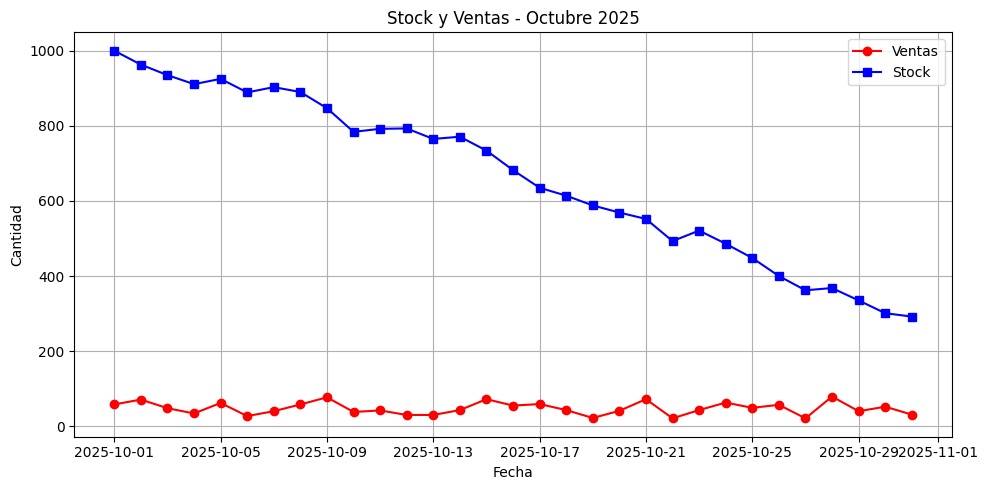

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Generar fechas (octubre de 2025)
fechas = pd.date_range(start="2025-10-01", end="2025-10-31")

# Generar datos simulados
np.random.seed(42)
ventas = np.random.randint(20, 80, size=len(fechas))
stock_inicial = 1000
stock = [stock_inicial]

# Calcular stock diario (restando ventas con reposiciones aleatorias)
for v in ventas[:-1]:
    nuevo_stock = max(stock[-1] - v + np.random.randint(0, 50), 0)
    stock.append(nuevo_stock)

# Crear DataFrame
df = pd.DataFrame({
    "Fecha": fechas,
    "Ventas": ventas,
    "Stock": stock
})

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(df["Fecha"], df["Ventas"], label="Ventas", marker="o", color="red")
plt.plot(df["Fecha"], df["Stock"], label="Stock", marker="s", color="blue")
plt.title("Stock y Ventas - Octubre 2025")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
!wget https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_MEX_shp.zip
!unzip gadm41_MEX_shp.zip


"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"unzip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


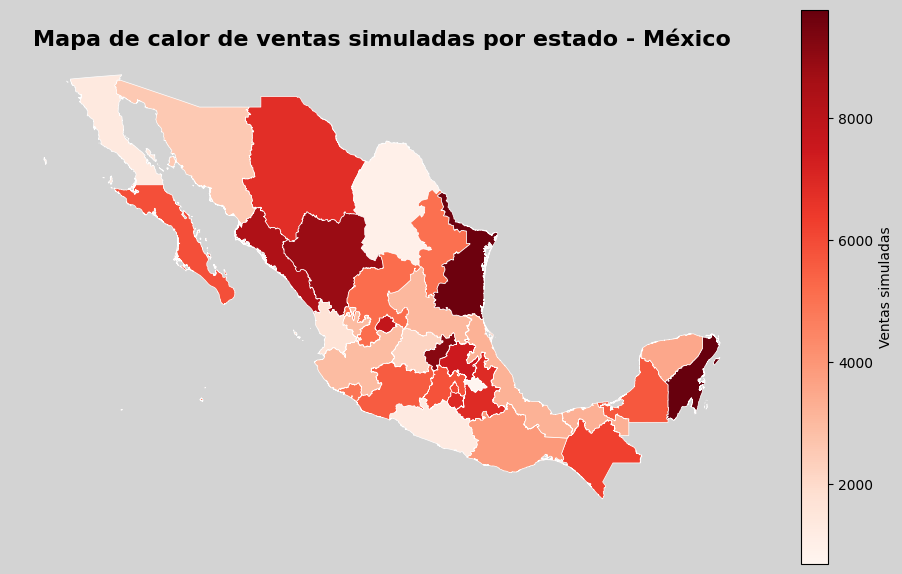

In [40]:
# --- Librerías necesarias ---
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Descargar y descomprimir shapefile de México ---
if not os.path.exists("gadm41_MEX_shp.zip"):
    !wget https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_MEX_shp.zip
    !unzip gadm41_MEX_shp.zip

# --- Cargar shapefile de niveles administrativos ---
mexico_estados = gpd.read_file("gadm41_MEX_shp/gadm41_MEX_1.shp")

# --- Crear datos simulados de ventas por estado ---
np.random.seed(42)
ventas = np.random.randint(500, 10000, size=len(mexico_estados))
df_ventas = pd.DataFrame({
    "NAME_1": mexico_estados["NAME_1"],
    "ventas": ventas
})

# --- Unir los datos simulados al mapa ---
mexico_estados = mexico_estados.merge(df_ventas, on="NAME_1")

# --- Graficar heatmap ---
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
mexico_estados.plot(
    column="ventas", 
    cmap="Reds",        # paleta más atractiva
    linewidth=0.5, 
    edgecolor="white",    # bordes blancos suaves
    legend=True, 
    legend_kwds={'shrink': 0.6, 'label': "Ventas simuladas"}, 
    ax=ax
)

# --- Estética final ---
ax.set_title("Mapa de calor de ventas simuladas por estado - México", fontsize=16, fontweight='bold')
ax.axis("off")
fig.patch.set_facecolor('lightgrey')  # fondo del mapa

plt.show()
fig.savefig("heatmap_ventas_mexico.png", dpi=300, bbox_inches="tight")



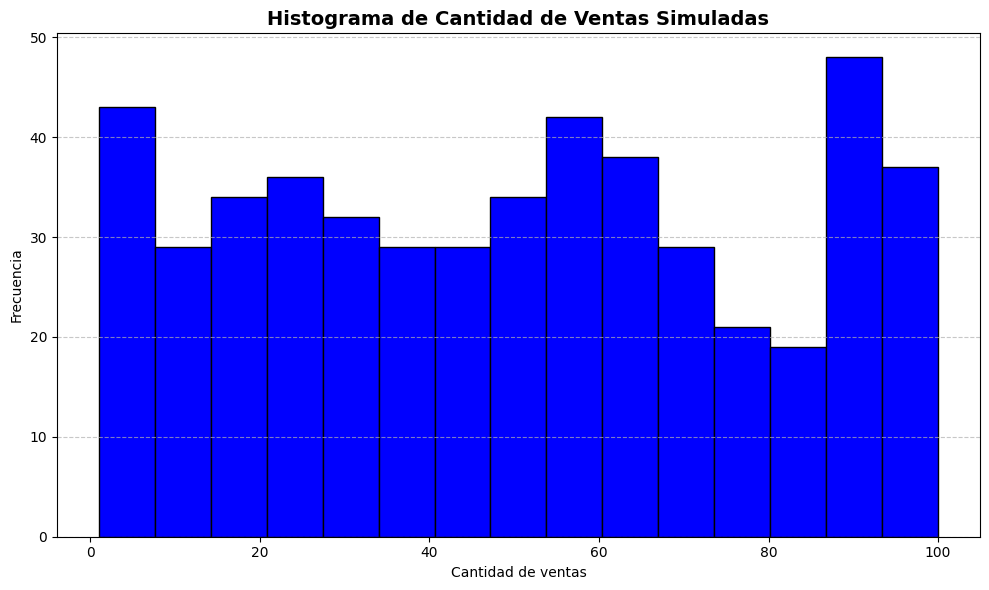

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generar datos simulados ---
np.random.seed(42)
# Por ejemplo, 500 ventas con cantidades entre 1 y 100
ventas_simuladas = np.random.randint(1, 101, size=500)

# --- Graficar histograma ---
plt.figure(figsize=(10,6))
plt.hist(ventas_simuladas, bins=15, color='blue', edgecolor='black')
plt.title("Histograma de Cantidad de Ventas Simuladas", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de ventas")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


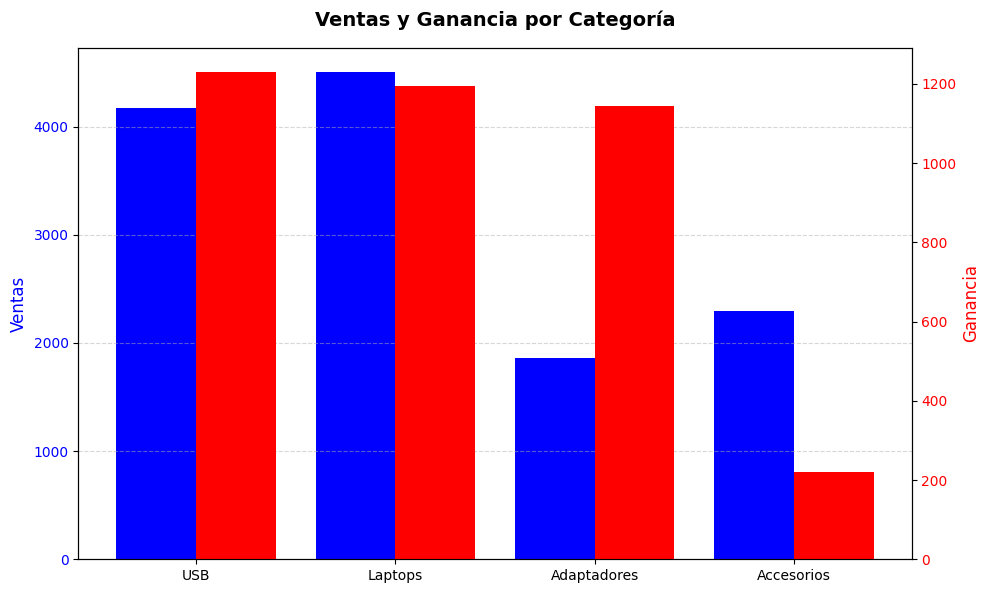

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- Datos simulados ---
categorias = ['USB', 'Laptops', 'Adaptadores', 'Accesorios']
np.random.seed(42)
ventas = np.random.randint(1000, 5000, size=len(categorias))
ganancias = np.random.randint(100, 1500, size=len(categorias))

# --- Configuración del gráfico ---
x = np.arange(len(categorias))
width = 0.4  # ancho de las barras

fig, ax1 = plt.subplots(figsize=(10,6))

# Barras de ventas (eje izquierdo)
barras_ventas = ax1.bar(x - width/2, ventas, width, color='blue', label='Ventas')
ax1.set_ylabel('Ventas', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(categorias)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Barras de ganancias (eje derecho)
ax2 = ax1.twinx()
barras_ganancias = ax2.bar(x + width/2, ganancias, width, color='red', label='Ganancia')
ax2.set_ylabel('Ganancia', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Añadir título
fig.suptitle('Ventas y Ganancia por Categoría', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


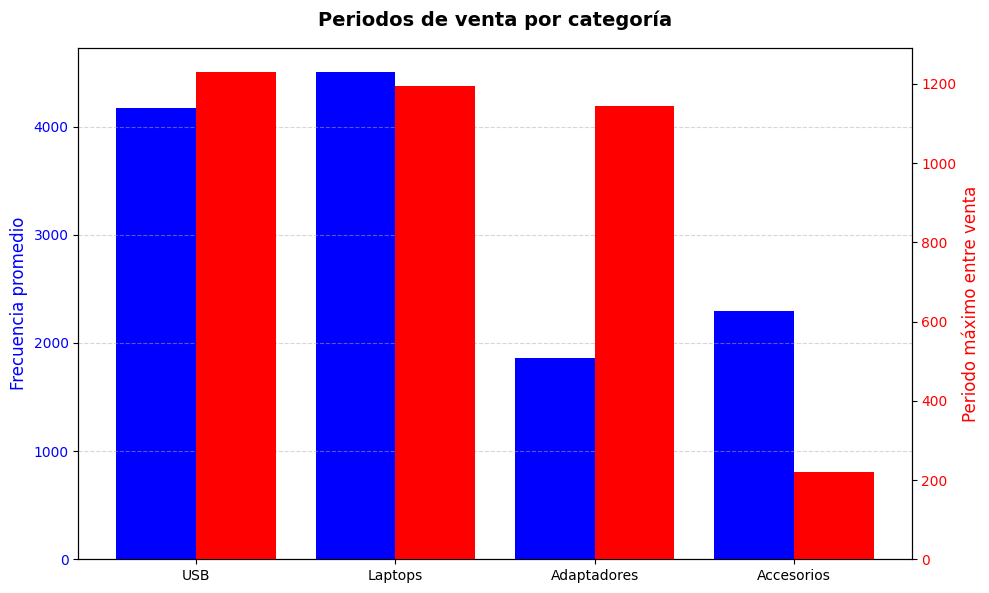

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- Datos simulados ---
categorias = ['USB', 'Laptops', 'Adaptadores', 'Accesorios']
np.random.seed(42)
ventas = np.random.randint(1000, 5000, size=len(categorias))
ganancias = np.random.randint(100, 1500, size=len(categorias))

# --- Configuración del gráfico ---
x = np.arange(len(categorias))
width = 0.4  # ancho de las barras

fig, ax1 = plt.subplots(figsize=(10,6))

# Barras de ventas (eje izquierdo)
barras_ventas = ax1.bar(x - width/2, ventas, width, color='blue', label='Frecuencia promedio')
ax1.set_ylabel('Frecuencia promedio', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(categorias)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Barras de ganancias (eje derecho)
ax2 = ax1.twinx()
barras_ganancias = ax2.bar(x + width/2, ganancias, width, color='red', label='Periodo máximo entre venta')
ax2.set_ylabel('Periodo máximo entre venta', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Añadir título
fig.suptitle('Periodos de venta por categoría', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

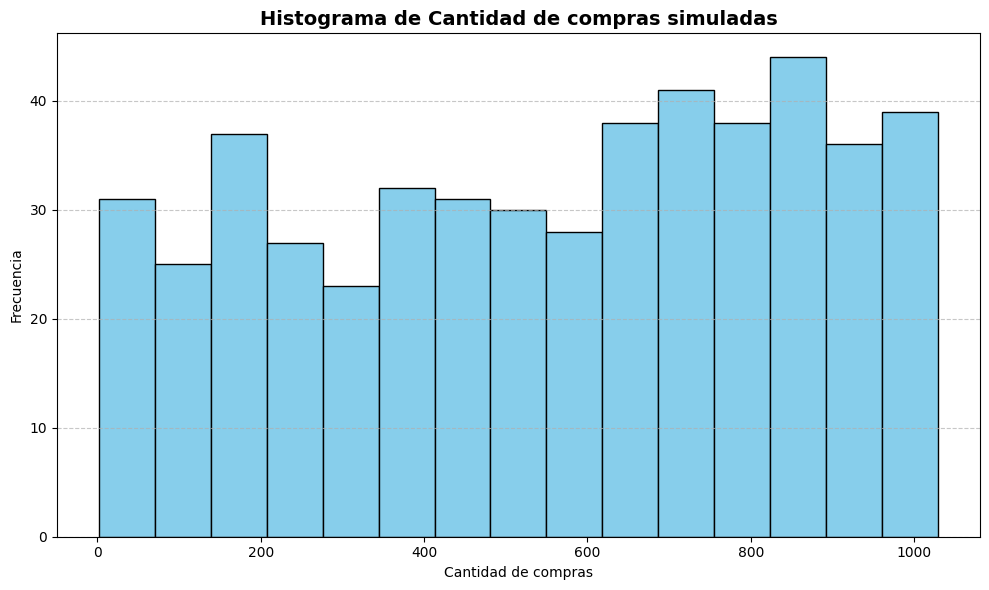

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generar datos simulados ---
np.random.seed(42)
# Por ejemplo, 500 ventas con cantidades entre 1 y 100
ventas_simuladas = np.random.randint(1, 1030, size=500)

# --- Graficar histograma ---
plt.figure(figsize=(10,6))
plt.hist(ventas_simuladas, bins=15, color='skyblue', edgecolor='black')
plt.title("Histograma de Cantidad de compras simuladas", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de compras")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


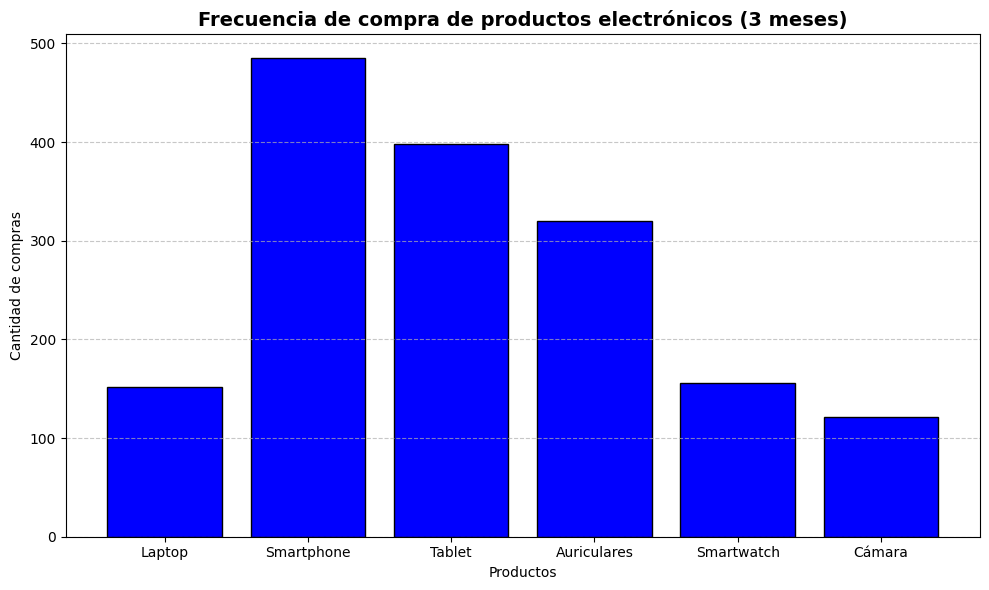

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- Productos electrónicos ---
productos = ['Laptop', 'Smartphone', 'Tablet', 'Auriculares', 'Smartwatch', 'Cámara']

# --- Simular frecuencia de compras en 3 meses ---
np.random.seed(42)
# Suponemos que cada producto tiene un número total de ventas acumuladas en 3 meses
frecuencias = np.random.randint(50, 500, size=len(productos))

# --- Graficar histograma / barras ---
plt.figure(figsize=(10,6))
plt.bar(productos, frecuencias, color='blue', edgecolor='black')
plt.title('Frecuencia de compra de productos electrónicos (3 meses)', fontsize=14, fontweight='bold')
plt.xlabel('Productos')
plt.ylabel('Cantidad de compras')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


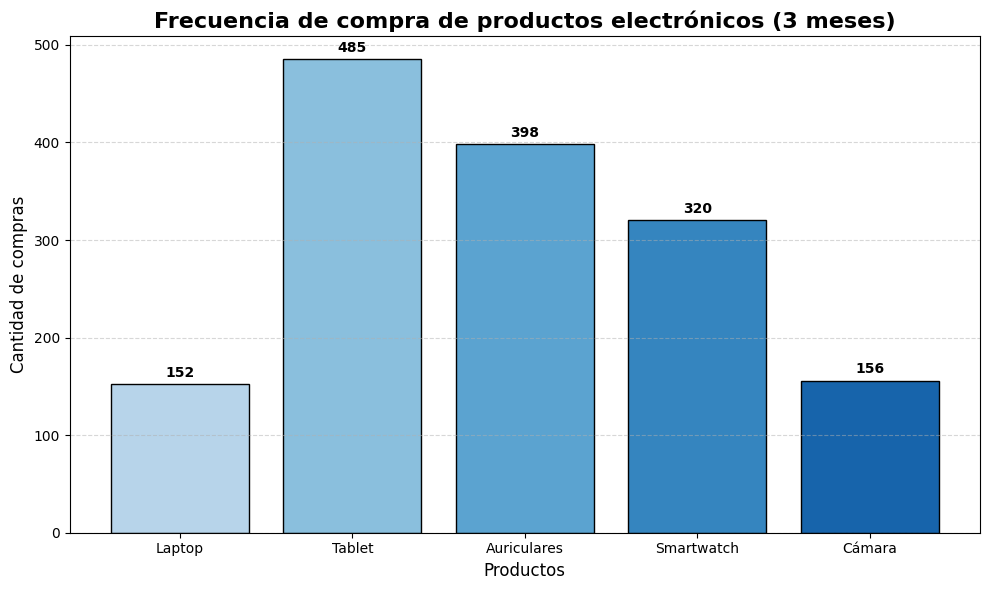

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- Productos electrónicos ---
productos = ['Laptop', 'Tablet', 'Auriculares', 'Smartwatch', 'Cámara']

# --- Simular frecuencia de compras en 3 meses ---
np.random.seed(42)
frecuencias = np.random.randint(50, 500, size=len(productos))

# --- Colores con gradiente ---
colores = plt.cm.Blues(np.linspace(0.3, 0.8, len(productos)))

# --- Graficar histograma premium ---
plt.figure(figsize=(10,6))
barras = plt.bar(productos, frecuencias, color=colores, edgecolor='black')

# --- Etiquetas sobre cada barra ---
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2, 
        altura + 5,  # un poco arriba de la barra
        str(altura),
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# --- Estética ---
plt.title('Frecuencia de compra de productos electrónicos (3 meses)', fontsize=16, fontweight='bold')
plt.xlabel('Productos', fontsize=12)
plt.ylabel('Cantidad de compras', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


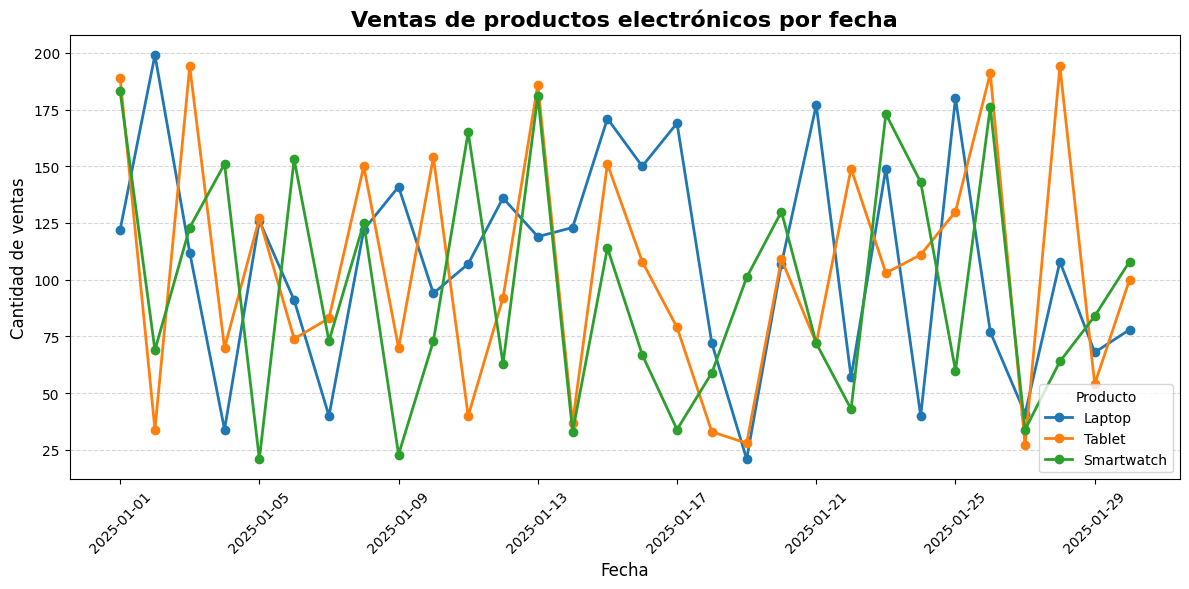

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Fechas (por ejemplo, un mes) ---
fechas = pd.date_range(start='2025-01-01', periods=30)

# --- Productos ---
productos = ['Laptop', 'Tablet', 'Smartwatch']

# --- Generar ventas simuladas por producto ---
np.random.seed(42)
ventas = {producto: np.random.randint(20, 200, size=len(fechas)) for producto in productos}

# --- Crear DataFrame ---
df_ventas = pd.DataFrame(ventas, index=fechas)

# --- Graficar ---
plt.figure(figsize=(12,6))
for producto in productos:
    plt.plot(df_ventas.index, df_ventas[producto], marker='o', linewidth=2, label=producto)

# --- Estética ---
plt.title('Ventas de productos electrónicos por fecha', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de ventas', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Producto')
plt.tight_layout()
plt.show()


In [36]:
import pandas as pd
import numpy as np

# --- Simulación de datos ---
np.random.seed(42)
n_clientes = 10

clientes = [f'Cliente_{i+1}' for i in range(n_clientes)]
frecuencia_promedio_compra = np.random.randint(1, 10, n_clientes)
variedad_de_productos = np.random.randint(1, 8, n_clientes)
compras_conjunto = np.random.randint(0, 5, n_clientes)
ganancias_por_trimestre = np.random.randint(100, 5000, n_clientes)

productos = ['Laptop', 'Smartphone', 'Tablet', 'Auriculares', 'Smartwatch', 'Cámara']
categorias = ['Electrónica', 'Componentes', 'Gaming', 'Hogar']

producto_favorito = np.random.choice(productos, n_clientes)
categoria_favorita = np.random.choice(categorias, n_clientes)

# --- Crear DataFrame ---
df_clientes = pd.DataFrame({
    'cliente': clientes,
    'frecuencia_promedio_compra': frecuencia_promedio_compra,
    'variedad_de_productos': variedad_de_productos,
    'compras_conjunto': compras_conjunto,
    'ganancias_por_trimestre': ganancias_por_trimestre,
    'producto_favorito': producto_favorito,
    'categoria_favorita': categoria_favorita
})

# --- Mostrar DataFrame ---
df_clientes.head()


,cliente,frecuencia_promedio_compra,variedad_de_productos,compras_conjunto,ganancias_por_trimestre,producto_favorito,categoria_favorita
0,Cliente_1,7,3,0,2147,Laptop,Componentes
1,Cliente_2,4,6,3,2847,Tablet,Componentes
2,Cliente_3,8,5,1,1075,Smartwatch,Componentes
3,Cliente_4,5,2,4,1906,Tablet,Electrónica
4,Cliente_5,7,4,3,289,Smartwatch,Componentes


In [42]:
import pandas as pd
import numpy as np

# --- Simulación de datos ---
np.random.seed(42)
n_clientes = 10

clientes = ["Código","Producto Sustituto","Productos Acompañados","Día más vendido","Clientes frecuentes"]
frecuencia_promedio_compra = ["AA2013","AA2134","VSCT291,A21C","Lunes","COL1010,MOR0095"]


# --- Crear DataFrame ---
df_clientes = pd.DataFrame({
    'cliente': clientes,
    'frecuencia_promedio_compra': frecuencia_promedio_compra,
})

# --- Mostrar DataFrame ---
df_clientes.head()

,cliente,frecuencia_promedio_compra
0,Código,AA2013
1,Producto Sustituto,AA2134
2,Productos Acompañados,"VSCT291,A21C"
3,Día más vendido,Lunes
4,Clientes frecuentes,"COL1010,MOR0095"


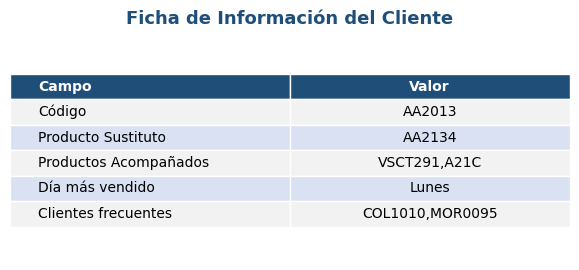

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Datos ---
clientes = ["Código","Producto Sustituto","Productos Acompañados","Día más vendido","Sucursal frecuente"]
frecuencia_promedio_compra = ["AA2013","AA2134","VSCT291,A21C","Lunes","HMO"]

# --- Crear DataFrame vertical ---
df_tabla = pd.DataFrame({
    'Campo': clientes,
    'Valor': frecuencia_promedio_compra
})

# --- Configurar figura ---
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.axis('off')

# --- Crear tabla ---
tabla = ax.table(
    cellText=df_tabla.values,
    colLabels=df_tabla.columns,
    cellLoc='center',   # alineación por defecto
    loc='center'
)

# --- Estilo visual premium ---
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.3, 1.5)

for (i, j), cell in tabla.get_celld().items():
    # Encabezado
    if i == 0:
        cell.set_facecolor('#1f4e79')  # azul oscuro
        cell.set_text_props(weight='bold', color='white', ha='center')
    # Filas pares e impares con distinto tono
    elif i % 2 == 0:
        cell.set_facecolor('#d9e1f2')  # azul claro
    else:
        cell.set_facecolor('#f2f2f2')  # gris muy claro

    # Alineación del texto
    if j == 0:  # Columna "Campo"
        cell._loc = 'left'  # alineado a la izquierda
        cell.set_text_props(ha='left', x=0.05)
    else:  # Columna "Valor"
        cell._loc = 'center'

    # Bordes limpios
    cell.set_edgecolor('white')

# --- Título ---
plt.title("Ficha de Información del Cliente", fontsize=13, fontweight='bold', color='#1f4e79', pad=12)
plt.tight_layout()
plt.show()


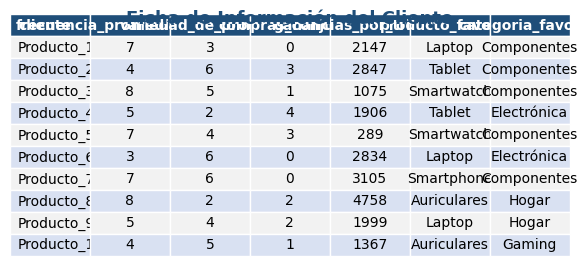

In [48]:
import pandas as pd
import numpy as np

# --- Simulación de datos ---
np.random.seed(42)
n_clientes = 10

clientes = [f'Producto_{i+1}' for i in range(n_clientes)]
frecuencia_promedio_compra = np.random.randint(1, 10, n_clientes)
variedad_de_productos = np.random.randint(1, 8, n_clientes)
compras_conjunto = np.random.randint(0, 5, n_clientes)
ganancias_por_trimestre = np.random.randint(100, 5000, n_clientes)

productos = ['Laptop', 'Smartphone', 'Tablet', 'Auriculares', 'Smartwatch', 'Cámara']
categorias = ['Electrónica', 'Componentes', 'Gaming', 'Hogar']

producto_favorito = np.random.choice(productos, n_clientes)
categoria_favorita = np.random.choice(categorias, n_clientes)

# --- Crear DataFrame ---
df_clientes = pd.DataFrame({
    'cliente': clientes,
    'frecuencia_promedio_compra': frecuencia_promedio_compra,
    'variedad_de_productos': variedad_de_productos,
    'compras_conjunto': compras_conjunto,
    'ganancias_por_trimestre': ganancias_por_trimestre,
    'producto_favorito': producto_favorito,
    'categoria_favorita': categoria_favorita
})

# --- Mostrar DataFrame ---
# --- Configurar figura ---
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.axis('off')

# --- Crear tabla ---
tabla = ax.table(
    cellText=df_clientes.values,
    colLabels=df_clientes.columns,
    cellLoc='center',   # alineación por defecto
    loc='center'
)

# --- Estilo visual premium ---
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.3, 1.5)

for (i, j), cell in tabla.get_celld().items():
    # Encabezado
    if i == 0:
        cell.set_facecolor('#1f4e79')  # azul oscuro
        cell.set_text_props(weight='bold', color='white', ha='center')
    # Filas pares e impares con distinto tono
    elif i % 2 == 0:
        cell.set_facecolor('#d9e1f2')  # azul claro
    else:
        cell.set_facecolor('#f2f2f2')  # gris muy claro

    # Alineación del texto
    if j == 0:  # Columna "Campo"
        cell._loc = 'left'  # alineado a la izquierda
        cell.set_text_props(ha='left', x=0.05)
    else:  # Columna "Valor"
        cell._loc = 'center'

    # Bordes limpios
    cell.set_edgecolor('white')

# --- Título ---
plt.title("Ficha de Información del Cliente", fontsize=13, fontweight='bold', color='#1f4e79', pad=12)
plt.tight_layout()
plt.show()



## Carga de datos

In [4]:
import os
from dotenv import load_dotenv
from pymongo import MongoClient
import pandas as pd

load_dotenv()

conn_uri = os.getenv("MONGO_URI")
mongo_db = os.getenv("MONGO_DB")
existence_table = os.getenv("EXISTENCE_COLLECTION")
branches_table = os.getenv("BRANCHES_COLLECTION")

client = MongoClient(conn_uri)
db = client[mongo_db]

collections={"existence":db[existence_table], "branches": db[branches_table] }

dataframes={}
query={"almacenes.existencia": {"$gt": 0}}

for name,collection in collections.items():
    cursor=collection.find()
    docs = list(cursor)

    df = pd.DataFrame(docs)

    dataframes[name]= df

In [8]:
dataframes["existence"].to_csv("data/existencia.csv")
dataframes["branches"].to_csv("data/almacen.csv")

In [10]:
branches = dataframes["branches"]
branches

,_id,nemonico,sucursal,homoclave,correos,__v,activo,connect,partnerCT,logs
0,5873d0da1f499c4c44fef1cc,02A,"CD. OBREGON, SON.",OBR,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,False,True,True,NaN
1,5877a80d42ea2e6bcc39c698,06A,"TORREON, COAH.",TRN,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,True,True,NaN
2,5894cede8c99807baf01aabb,03A,"LOS MOCHIS, SIN",LMO,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,True,True,NaN
3,5894cef98c99807baf01aabc,04A,CULIACAN SIN.,CLN,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,False,True,NaN
4,5894cf138c99807baf01aabd,05A,"DURANGO, DGO.",DGO,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,True,True,NaN
5,5894cffa8c99807baf01aabf,07A,"CHIHUAHUA, CHIH.",CHI,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'ECO...",0,False,True,True,NaN
6,5894d0468c99807baf01aac0,09A,"QUERETARO, QUERETARO",QRO,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,True,False,NaN
7,5894d0ac8c99807baf01aac1,10A,SAN LUIS POTOSI,SLP,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,True,False,NaN
8,5894f56242c0fb21529d4dc6,01A,"HERMOSILLO, SON.",HMO,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,True,False,"[{'usuario': 'gerardo.leyva3', 'fecha': 2023-1..."
9,5894f8ab31a936223c7ff464,11A,"LEON, GUANAJUATO",LE,"[{'correo': 'ecom@ctin.com.mx', 'nombre': 'eco...",0,True,True,False,NaN


In [18]:
existence = dataframes["existence"]


In [24]:
def get_existence(existences:list)->int:
    global_existence = 0
    for branch in existences:
       global_existence += branch["existencia"]
    return global_existence

In [26]:
existence["stock"] = existence["almacenes"].apply(lambda x: get_existence(x) )

exists = existence["stock"]>0
existence[exists]

,_id,codigo,activo,fechaRegistro,listaPrecios,existencia,almacenes,codigoSAT,updatedExistencia,updateExistencia,stock
9,5afdc7f9a33754bf8905f133,ACCAOC010,True,2025-09-03 16:45:33.038,"{'precio1': 100, 'precio2': 100, 'precio3': 10...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 0}, {'almace...",53121700,2023-06-14 17:51:46.495,2023-01-20 21:34:12.201,10.0
29,5afdc7f9a33754bf8905f17a,ACCCDM1080,True,2025-09-03 16:45:32.832,"{'precio1': 2364.88, 'precio2': 2310.52, 'prec...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 0}, {'almace...",26121600,2024-06-17 21:20:02.385,2023-01-20 21:34:12.331,24.0
30,5afdc7f9a33754bf8905f17b,ACCCDM1010,True,2025-09-03 16:45:32.784,"{'precio1': 2980.21, 'precio2': 2980.21, 'prec...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 8}, {'almace...",26121609,2024-06-17 21:20:01.901,2023-01-20 21:34:12.329,152.0
32,5afdc7f9a33754bf8905f17e,ACCCDM1040,True,2025-09-03 16:45:32.826,"{'precio1': 3370.67, 'precio2': 3370.67, 'prec...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 0}, {'almace...",26121609,2024-06-17 21:20:02.019,2023-01-20 21:34:12.330,3.0
35,5afdc7f9a33754bf8905f18e,ACCCDM1230,True,2025-09-03 16:45:32.823,"{'precio1': 2258.82, 'precio2': 2206.9, 'preci...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 3}, {'almace...",26121609,2024-06-17 21:20:02.260,2023-01-20 21:34:12.332,161.0
...,...,...,...,...,...,...,...,...,...,...,...
107726,68b08071b71d03fe4c5f62a6,MONAOC880,True,2025-09-03 16:45:33.321,"{'precio1': 2165.37, 'precio2': 2142.81, 'prec...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 0}, {'almace...",43211900,NaT,NaT,1.0
107880,68b1f2ebb71d03fe4cea1317,CARXRX7480,True,2025-09-03 16:45:33.098,"{'precio1': 106.5, 'precio2': 106.5, 'precio3'...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 0}, {'almace...",44103103,NaT,NaT,96.0
107891,68b5e85cb71d03fe4c2e74bb,ACCPTS2360,True,2025-09-03 16:45:33.249,"{'precio1': 3353.48, 'precio2': 3353.48, 'prec...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 0}, {'almace...",52161514,NaT,NaT,60.0
107898,68b5e85db71d03fe4c2e74ea,ACCPTS2350,True,2025-09-03 16:45:33.096,"{'precio1': 3353.48, 'precio2': 3353.48, 'prec...","{'pedido': 0, 'asignado': 0}","[{'almacen': '01A', 'existencia': 0}, {'almace...",52161514,NaT,NaT,10.0


In [ ]:
df = pd.read_csv("data/processed.csv")
df

,Unnamed: 0.1,productId,FOLIO,cantidad,fecha,price,COSTEO,client,SUCURSAL,Unnamed: 0,PRODUCTO,DESCRIPCION,mes,año,sales_day,sales_month,sales_freq,profit,total_profit
0,5,SUBCCT010,HMO1076435,1,2025-01-01,600.00,0.0,ZAC0039,HMO,90383.0,SUBCCT010,SUSCRIPCION MENSUAL PARTNER CT,1,2025,18,183,18,600.00,1.760340e+06
1,21,SUBCCT010,HMO1076436,1,2025-01-01,600.00,0.0,TXA0070,HMO,90383.0,SUBCCT010,SUSCRIPCION MENSUAL PARTNER CT,1,2025,18,183,18,600.00,1.760340e+06
2,37,SUBCCT010,HMO1076437,1,2025-01-01,600.00,0.0,CDV0050,HMO,90383.0,SUBCCT010,SUSCRIPCION MENSUAL PARTNER CT,1,2025,18,183,18,600.00,1.760340e+06
3,43,SUBCCT010,HMO1076456,1,2025-01-01,600.00,0.0,MXL0446,HMO,90383.0,SUBCCT010,SUSCRIPCION MENSUAL PARTNER CT,1,2025,18,183,18,600.00,1.760340e+06
4,53,SUBCCT010,HMO1076438,1,2025-01-01,600.00,0.0,TPC0230,HMO,90383.0,SUBCCT010,SUSCRIPCION MENSUAL PARTNER CT,1,2025,18,183,18,600.00,1.760340e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536840,4318223,SERCDP030,TJN568414,1,2025-11-11,2222.22,2000.0,TJN1794,TJN,43831.0,SERCDP030,VIATICOS CDP,11,2025,1,1,1,2222.22,5.888890e+03
536841,4318224,PAQLOC010,TJN568414,1,2025-11-11,7777.78,0.0,TJN1794,TJN,57168.0,PAQLOC010,SERVICIO DE EMPAQUE Y DE MATERIALES,11,2025,37,270,29,7777.78,5.442909e+06
536842,4318225,BATCDP230,TJN568414,1,2025-11-11,24045.52,21641.0,TJN1794,TJN,NaN,NaN,NaN,11,2025,1,1,1,24045.52,2.404552e+04
536843,4318236,ESDEST790,HMO1145418,1,2025-11-12,361.61,454.6,VER2709,HMO,21072.0,ESDEST790,ESET HOME SEC ESSEN 1 L 1 A TMESET-410,11,2025,1,7,1,361.61,1.025430e+05


In [27]:
import mysql.connector
import os
from dotenv import load_dotenv

load_dotenv()

ip=os.getenv("CDB_IP")
user=os.getenv("CDB_UID")
password=os.getenv("CDB_PASSWORD")
database=os.getenv('CDB_DATABASE')
category_table=os.getenv('CDB_CATEGORY_TABLE')
product_table=os.getenv('CDB_PRODUCT_TABLE')



conn_mysql = mysql.connector.connect(
    host=ip,
    user=user,
    password=password,
    database=database
)

cursor = conn_mysql.cursor(dictionary=True)  # devuelve resultados como diccionarios

cursor.execute(f"SELECT * FROM {category_table};")
rows_category = cursor.fetchall()

cursor.execute(f"SELECT * FROM {product_table};")
rows_products = cursor.fetchall()
cursor.close()
conn_mysql.close()

categories = pd.DataFrame(rows_category)
products = pd.DataFrame(rows_products)

categories.to_parquet("data/categorias.parquet")
products.to_parquet("data/productos.parquet")

In [28]:
products

,idProductos,idCategoria,idMarca,clave,tipo,codigoSat,modelo,numParte,descripcion,fechaAlta,...,busqueda,palabrasClave,busqueda_preview,descripcion_corta_icecat,descripcion_icecat,compraMinima,icecatFiltros,fechaRegistro,protegido,activo
0,0,0,6,PANIQB020,Lector de Memoria,None,-a,TXR-190,Características: Interno,2012-09-24,...,PANIQB020 Lector de Memoria -a TXR-190 Accesor...,Palabras,None,,,0,0,None,0,0
1,1,97,6,AACACT970,Lector de memoria,None,TXR-190,TXR-190,0,2011-06-01,...,AACACT970 Lector de memoria ACTECK TXR-190 - ...,None,Lector de memoria Lectores de Memorias ACTECK ...,"Lector de memoria ACTECK, Negro",0,0,2,None,0,0
2,3,116,3,ACC3M030,Pantalla de Proyección,None,MQ300000667,-,Dimensiones: Pared 2.14 X 2.14 mts,2011-06-01,...,ACC3M030 Pantalla de Proyección MQ300000667 - ...,None,Pantalla de Proyección Pantallas de Proyección...,,,0,0,None,0,1
3,4,116,3,ACC3M050,Pantalla de Proyección,None,MQ300000642,-,Dimensiones: Pared 1.78 X 1.78 mts,2011-06-01,...,ACC3M050 Pantalla de Proyección MQ300000642 - ...,None,Pantalla de Proyección Pantallas de Proyección...,,,0,0,None,0,1
4,6,116,3,ACC3M090,Pantalla de Proyección,None,MQ300000048,-,Dimensiones: Pared 2.44 X 2.44 mts,2011-06-01,...,ACC3M090 Pantalla de Proyección MQ300000048 - ...,None,Pantalla de Proyección Pantallas de Proyección...,,,0,0,None,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62652,68283,169,696,VENDCO430,Disipador,None,AG400 PLUS,R-AG400-BKNNMD-G,0,2025-11-12,...,VENDCO430 AG400 PLUS DeepCool Enfriamiento y V...,None,None,Disipador Gaming DEEPCOOL AG400 PLUS (R-AK620-...,0,0,2,2025-11-12,0,1
62653,68284,169,696,VENDCO450,Enfriamiento liquido,None,LD240,R-LD240-BKMSN-G-1,0,2025-11-12,...,VENDCO450 LD240 DeepCool Enfriamiento y Ventil...,None,None,Enfriamiento Liquido Gaming DEEPCOOL LD240 (R-...,0,0,2,2025-11-12,0,1
62654,68285,169,696,VENDCO540,Enfriamiento y Ventilación,None,AK500 DIGITAL PRO,R-AK500-BKAPMN-G,0,2025-11-12,...,VENDCO540 AK500 DIGITAL PRO DeepCool Enfriamie...,None,None,Disipador Gaming DEEPCOOL AK500 DIGITAL PRO (R...,0,0,2,2025-11-12,0,1
62655,68286,169,696,VENDCO560,Enfriamiento y Ventilación,None,AG620 ARGB,R-AG620-BKANMN-G-1,0,2025-11-12,...,VENDCO560 AG620 ARGB DeepCool Enfriamiento y V...,None,None,Disipador Gaming DEEPCOOL AG620 ARGB (R-AK620-...,0,0,2,2025-11-12,0,1


In [29]:
df=pd.read_csv("data/existencia.csv")

C:\Users\federico.cirett\AppData\Local\Temp\ipykernel_25084\2924173406.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("data/existencia.csv")


In [37]:
def get_existence(existences:list)->int:
    global_existence = 0
    for branch in existences:
       print(existences)
       print(branch)
       global_existence += branch["existencia"]
    return global_existence

In [38]:
df["stock"] = df["almacenes"].apply(lambda x: get_existence(x) )

[{'almacen': '01A', 'existencia': 0}, {'almacen': '02A', 'existencia': 0}, {'almacen': '03A', 'existencia': 0}, {'almacen': '04A', 'existencia': 0}, {'almacen': '05A', 'existencia': 0}, {'almacen': '06A', 'existencia': 0}, {'almacen': '07A', 'existencia': 0}, {'almacen': '08A', 'existencia': 0}, {'almacen': '09A', 'existencia': 0}, {'almacen': '10A', 'existencia': 0}, {'almacen': '11A', 'existencia': 0}, {'almacen': '12A', 'existencia': 0}, {'almacen': '13A', 'existencia': 0}, {'almacen': '14A', 'existencia': 0}, {'almacen': '15A', 'existencia': 0}, {'almacen': '16A', 'existencia': 0}, {'almacen': '17A', 'existencia': 0}, {'almacen': '18A', 'existencia': 0}, {'almacen': '19A', 'existencia': 0}, {'almacen': '20A', 'existencia': 0}, {'almacen': '21A', 'existencia': 0}, {'almacen': '22A', 'existencia': 0}, {'almacen': '23A', 'existencia': 0}, {'almacen': '24A', 'existencia': 0}, {'almacen': '25A', 'existencia': 0}, {'almacen': '26A', 'existencia': 0}, {'almacen': '27A', 'existencia': 0}, 

TypeError: string indices must be integers, not 'str'

In [1]:
from src.preprocess import process_data
import pandas as pd

df= process_data()
df

2025-11-14 10:58:00.813 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


,productId,FOLIO,cantidad,fecha,price,COSTEO,client,SUCURSAL,Unnamed: 0,PRODUCTO,...,sales_month,sales_freq,profit,total_profit,clave,category,cat_sales_day,cat_sales_month,state,stock
0,MEMDAT6830,PUE475564,2,2025-01-01,25.11,950.3016,MOR1542,PUE,54547,MEMDAT6830,...,35,1,50.22,2.266074e+04,MEMDAT6830,Memorias RAM,9.0,13404.0,PUEBLA,1008.000000
1,SUBCCT010,HMO1076435,1,2025-01-01,600.00,0.0000,ZAC0039,HMO,90383,SUBCCT010,...,205,18,600.00,1.956204e+06,NaN,NaN,NaN,NaN,SONORA,1018.999590
2,DDUACR220,CUE231578,1,2025-01-01,60.17,1052.8308,GDL1473D,CUE,21285,DDUACR220,...,99,1,60.17,9.999530e+03,DDUACR220,SSD,13.0,43997.0,MORELOS,984.999181
3,ACCPCM1160,DFP218210,1,2025-01-01,750.00,645.0000,GDL2988,DFP,21375,ACCPCM1160,...,2455,1,750.00,1.980874e+07,ACCPCM1160,Rollos de papel,1.0,6852.0,CIUDAD DE MÉXICO,1018.998771
4,CJNNTE010,TUX571329,5,2025-01-01,501.14,2201.1425,TXA2613,TUX,94340,CJNNTE010,...,369,1,2505.70,1.824277e+06,CJNNTE010,Cajones de Dinero,5.0,1763.0,CHIAPAS,1017.998362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1953108,PANSCR120,DFA673650,1,2025-11-11,187.06,3021.3000,HMO2926,DFA,8016,PANSCR120,...,15,1,187.06,7.851720e+03,PANSCR120,Pantallas de Proyección,7.0,58.0,CIUDAD DE MÉXICO,188.001638
1953109,MEMDAT2890,TRN401170,5,2025-11-11,6.69,439.9739,TRN1491,TRN,22593,MEMDAT2890,...,2798,24,33.45,5.541164e+05,MEMDAT2890,Memorias Flash,2153.0,23131.0,COAHUILA,219.001229
1953110,SWTTPL1330,DFA673663,1,2025-11-12,251.78,4244.1047,GDL1473D,DFA,62397,SWTTPL1330,...,1,1,251.78,1.533560e+03,SWTTPL1330,Switches,1.0,3173.0,CIUDAD DE MÉXICO,188.000819
1953111,ESDEST790,HMO1145418,1,2025-11-12,361.61,454.6000,VER2709,HMO,21072,ESDEST790,...,7,1,361.61,1.025430e+05,ESDEST790,Aplicaciones de Seguridad,1.0,1100.0,SONORA,188.000410


In [ ]:
from src.graphs import sales_heat_map

sales_heat_map(df)

In [2]:
import geopandas as gpd
mexico_estados = gpd.read_file("gadm41_MEX_shp/gadm41_MEX_1.shp")
mexico_estados["state"] = mexico_estados["NAME_1"].str.upper()
mexico_estados = mexico_estados.merge(df, left_on="state",right_on="state")

mexico_estados

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,...,sales_day,sales_month,sales_freq,profit,total_profit,clave,category,cat_sales_day,cat_sales_month,stock
0,MEX.1_1,MEX,México,Aguascalientes,NA,NA,Estado,State,NA,MX.AG,...,2,19,2,32.78,5.614170e+03,KITTPL360,Extensores de Red,2.0,9658.0,987.990989
1,MEX.1_1,MEX,México,Aguascalientes,NA,NA,Estado,State,NA,MX.AG,...,2,19,2,32.78,5.614170e+03,KITTPL360,Extensores de Red,2.0,9658.0,1012.980339
2,MEX.1_1,MEX,México,Aguascalientes,NA,NA,Estado,State,NA,MX.AG,...,20,808,9,3.85,2.544025e+04,CABITL080,Cables VGA,24.0,1287.0,1012.934054
3,MEX.1_1,MEX,México,Aguascalientes,NA,NA,Estado,State,NA,MX.AG,...,6,264,6,120.00,2.277045e+05,KITTCH500,Kits para Teclado y Mouse,319.0,12854.0,1010.932416
4,MEX.1_1,MEX,México,Aguascalientes,NA,NA,Estado,State,NA,MX.AG,...,10,2282,4,3.46,6.856955e+04,TARMER020,Adaptadores USB Red,204.0,15174.0,984.932006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1738272,MEX.32_1,MEX,México,Zacatecas,NA,NA,Estado,State,NA,MX.ZA,...,16,66,5,256.11,1.138623e+06,BATBIT050,Baterías,280.0,1656.0,204.550096
1738273,MEX.32_1,MEX,México,Zacatecas,NA,NA,Estado,State,NA,MX.ZA,...,4,87,3,91.68,8.759792e+04,ACCMST4290,Cables USB,210.0,1652.0,188.456297
1738274,MEX.32_1,MEX,México,Zacatecas,NA,NA,Estado,State,NA,MX.ZA,...,1,1,1,12.03,6.338900e+02,ACCNEX330,Focos Inteligentes,1.0,2.0,206.455888
1738275,MEX.32_1,MEX,México,Zacatecas,NA,NA,Estado,State,NA,MX.ZA,...,163,276,8,1438.50,8.222988e+04,ROUMER090,Routers,774.0,7525.0,181.372329


In [8]:
is_product=df["productId"]=="ACCPCM1160"
df_filtered=df[is_product]

total_sales_per_state= df_filtered.groupby(["state"])["cantidad"].sum()
total_sales_per_state

state
AGUASCALIENTES          169
BAJA CALIFORNIA        2410
BAJA CALIFORNIA SUR    2231
CAMPECHE                134
CHIAPAS                1243
CHIHUAHUA              3500
CIUDAD DE MÉXICO        732
COAHUILA                743
COLIMA                  782
DURANGO                 408
ESTADO DE MÉXICO       1682
GUANAJUATO              481
GUERRERO                140
HIDALGO                 412
JALISCO                 421
MICHOACÁN              1449
MORELOS                 366
NAYARIT                 203
NUEVO LEÓN              523
OAXACA                  344
PUEBLA                  739
QUERÉTARO               344
QUINTANA ROO           1417
SAN LUIS POTOSÍ         637
SINALOA                2196
SONORA                 1065
TABASCO                 775
TAMAULIPAS              463
TLAXCALA                273
VERACRUZ                872
YUCATÁN                 297
ZACATECAS               783
Name: cantidad, dtype: int64

In [9]:
import matplotlib.pyplot as plt
def sales_heat_map(data:pd.DataFrame,productId:str):
    """ 
    Función que recibe el dataframe de datos del periodo especificado y 
    grafíca las ventas sobre un mapa de calor en méxico.
    """
    is_product=data["productId"]==productId
    df_filtered=data[is_product]

    total_sales_per_state= df_filtered.groupby(["state"])["cantidad"].sum()
    mexico_estados = gpd.read_file("gadm41_MEX_shp/gadm41_MEX_1.shp")
    mexico_estados["state"] = mexico_estados["NAME_1"].str.upper()
    mexico_estados = mexico_estados.merge(total_sales_per_state, left_on="state",right_on="state")
    
    
    # --- Graficar heatmap --- #
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    mexico_estados.plot(
        column="cantidad", 
        cmap="Reds",        # paleta más atractiva
        linewidth=0.5, 
        edgecolor="white",    # bordes blancos suaves
        legend=True, 
        legend_kwds={'shrink': 0.6, 'label': "Ventas"}, 
        ax=ax
    )

    # --- Estética --- #
    ax.set_title("Mapa de calor de ventas por estado ", fontsize=16, fontweight='bold')
    ax.axis("off")
    fig.patch.set_facecolor('lightgrey')  # fondo del mapa

    fig.savefig("plots/heatmap_ventas_mexico.png", dpi=300, bbox_inches="tight")
    plt.show()

In [10]:
product_id="ACCPCM1160"
sales_heat_map(df,product_id)

C:\Users\federico.cirett\AppData\Local\Temp\ipykernel_27440\2551787538.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [13]:
list(df["productId"].unique())

['MEMDAT6830',
 'SUBCCT010',
 'DDUACR220',
 'ACCPCM1160',
 'CJNNTE010',
 'IMPECL320',
 'CABITL4210',
 'VENBLR170',
 'DDUACR020',
 'IMPSTR1020',
 'CARGO100',
 'CABITL265',
 'VENBLR270',
 'DDUDAT520',
 'MEMDAT6260',
 'VENNCB090',
 'ACCDAT1460',
 'DDUDAT450',
 'KITTPL360',
 'NBKVIC690',
 'NBKCDP1670',
 'ESDKPK1820',
 'GABBLR320',
 'MOULEN060',
 'ACCTRG3480',
 'MEMDAT6200',
 'GABBLR390',
 'DDUDAT880',
 'REGCDP1060',
 'ACCZKT120',
 'TELPAN050',
 'MEMKGN2870',
 'GABDCO120',
 'DDUXPG080',
 'ESDEST810',
 'CAMTPL200',
 'DDUDAT870',
 'GABCOR1670',
 'GABEVO150',
 'MEMDAT6080',
 'DDUDAT1840',
 'MEMDAT2890',
 'DDUDAT1610',
 'KITNCB140',
 'GRDDAH920',
 'MOUTCH940',
 'MEMDAH020',
 'ACCRBT6460',
 'GRDDAH910',
 'ACCTCH9960',
 'DDUSAT260',
 'PROYAB010',
 'ACCPVS220',
 'ACCDAH650',
 'MEMDAT2490',
 'ACCPVS040',
 'ACCPVS260',
 'MEMDAH050',
 'ACCPVS460',
 'VENNCB180',
 'ACCPVS240',
 'SWTTPL155',
 'DDUDAT1290',
 'CAMDAH4030',
 'ACCEPS510',
 'MEMDAT6470',
 'NBKSKE070',
 'DDUDAT1300',
 'CPUINT3490',
 'BOCVGO47

In [ ]:
import pandas as pd
from src.preprocess import process_data
from src.graphs import top_n


def frequent_clients(data:pd.DataFrame,level:str="producto",n:int=5)->list[str]:
    level_dict={"producto":"productId"}
    df = data.groupby(["client","fecha",level_dict[level]]).value_counts(ascending=False)
    frequent_clients = list( df[:n])
    return frequent_clients

data=process_data()

freq_clients=frequent_clients(data)
freq_clients

[1, 1, 1, 1, 1]

In [7]:
freq_clients

[1, 1, 1, 1, 1]

In [ ]:
n=5
level="producto"
level_dict={"producto":"productId"}
df = data[["client","fecha"]].value_counts().to_frame("count")
df["mean"] = df.groupby(level="client")["count"].transform("mean") 

In [58]:
df[:7]["count"].sum()

np.int64(3496)

In [56]:
df = data[["client","fecha"]].value_counts().to_frame("count")
df["total"] = df.groupby(level="client")["count"].transform("sum") 
df

count  total
client  fecha                   
CJS0560 2025-11-07    872   7750
        2025-02-12    786   7750
        2025-01-27    489   7750
        2025-01-20    398   7750
        2025-05-30    334   7750
...                   ...    ...
13A     2025-05-30      1     19
        2025-06-09      1     19
29A     2025-02-18      1     20
        2025-05-06      1     20
        2025-06-10      1     20

[583284 rows x 2 columns]

In [86]:
def frequency(data:pd.DataFrame):
    data["fecha"] = pd.to_datetime(data["fecha"])
    start = data["fecha"].min().day
    end = data["fecha"].max().day

    period_length = end - start
    df = data[["client","fecha"]].value_counts().to_frame("count")
    df["total"] = df.groupby(level="client")["count"].transform("sum") 
    df["avg_rate"] = df["total"]/period_length
    df = df.reset_index()
    df = df[["client","avg_rate"]].drop_duplicates().reset_index().drop(columns="index")
    return df

test= frequency(data)

test.sort_values(by="avg_rate",ascending=False)


,client,avg_rate
13,HMO1889,1896.454545
5,GDL1473D,1758.636364
6,GDL1473,1635.272727
0,CJS0560,704.545455
12,OBR1657,698.000000
...,...,...
28019,DFP0309,0.090909
27983,ZAC0060,0.090909
27982,DFP1465,0.090909
27981,DFP1482,0.090909


In [102]:
def top_n(data:pd.DataFrame,type:str,criteria:str="ventas_diarias",n:int=5)->list[str]:
    """
    Recibe el dataframe de datos del periodo especificado y regresa los mejores
    'n' productos o categorías en base el criterio específicado.
    """
    type_dict= {"producto":"productId",
                "categoria":"category",
                "sucursal":"branch",
                "cliente":"client"}

    criteria_dict={"ventas_diarias":"sales_day",
                   "ventas_mensuales":"sales_month",
                   "ganancia_total":"total_profit"}
    
    if n==1:
        top_n= list( data[ criteria_dict[criteria] ].max()[type_dict[type]] )
        return 
    df= data[[type_dict[type],criteria_dict[criteria]]].sort_values(by=criteria_dict[criteria],ascending=False).drop_duplicates()[:n]

    top_n= list( df )

    return top_n

,productId,sales_day
1848099,MEMDAH090,42961
1913656,MEMSTY050,36582
58532,MEMSTY060,36070
1427410,MEMDAH020,30000
1914192,MEMSTY040,28793


In [105]:

def frequency(data:pd.DataFrame,type:str="cliente")->pd.DataFrame:
    """
    Recibe el dataframe de datos del periodo especificado y regresa los ritmos de ventas promedio
    en dicho periodo. 

    """
    type_dict= {"producto":"productId",
                "categoria":"category",
                "sucursal":"branch",
                "cliente":"client",
                "dia":"weekday"}
    
    column = type_dict[type]
    data["fecha"] = pd.to_datetime(data["fecha"])
    start = data["fecha"].min().day
    end = data["fecha"].max().day

    period_length = end - start
    df = data[[column,"fecha"]].value_counts().to_frame("count")
    df["total"] = df.groupby(level=column)["count"].transform("sum") 
    df["avg_rate"] = df["total"]/period_length
    df = df.reset_index()
    df = df[[column,"avg_rate"]].drop_duplicates().reset_index().drop(columns="index")
    return df


def top_day(data:pd.DataFrame)->str:
    data["fecha"] = pd.to_datetime(data["fecha"])
    data["weekday"]=data["fecha"].dt.weekday
    df = frequency(data,type="dia")
    df = df.sort_values(by="avg_rate",ascending=False)
    return df


test=top_day(data)
test

,weekday,avg_rate
0,2,33925.909091
1,1,33324.727273
4,3,32555.090909
2,4,32336.636364
3,0,31758.909091
5,5,13250.545455
6,6,403.909091


## Stock Cover vs Sales Velocity

In [122]:
import pandas as pd
from src.preprocess import process_data

df = process_data()

In [124]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

product = "CARHPP1020"
is_product= df["productId"]==product
df = df[is_product]
df["avg_daily_sales"] = df["sales_day"].expanding().mean()
df["stock_cover"] = df["stock"]/df["avg_daily_sales"]

df["sales_velocity"] = df["sales_day"].rolling(window=7).mean()

df["fecha"] = pd.to_datetime(data["fecha"], errors="coerce")

    # Eliminar filas con fechas inválidas que causen el 1970-01-01
#data = data.dropna(subset=["fecha"]).sort_values("fecha")

plt.figure(figsize=(12, 6))
plt.style.use("seaborn-v0_8")

    # Líneas interpoladas
#plt.scatter(df["sales_velocity"], df["stock_cover"], label="Ventas", marker="o", color="#e63946")
plt.plot(df["fecha"], df["sales_velocity"], label="Velocidad de Ventas (ventas/día)", marker="o", color="#e63946")
plt.plot(df["fecha"],  df["stock_cover"],     label="Stock Cover", marker="s", color="#457b9d")


    # Título y etiquetas
plt.title("Stock y Ventas (Interpolado)", fontsize=16, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")

    # --- Eje X limpio ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
 
plt.xticks(rotation=45, ha="right")

    # Sin grid
plt.grid(False)

plt.legend()
plt.tight_layout()
plt.savefig("plots/almacen_v_rapidez_ventas.png")
plt.show()


C:\Users\federico.cirett\AppData\Local\Temp\ipykernel_9860\1702684975.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## ABC Analysis Chart


In [33]:
import pandas as pd
from src.preprocess import process_data

df = process_data()

c:\Users\federico.cirett\Documents\ct_dashboard\src\preprocess.py:61: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  existence= pd.read_csv("data/existencia.csv")


In [15]:
df.head()

,productId,FOLIO,cantidad,fecha,price,COSTEO,client,SUCURSAL,Unnamed: 0,PRODUCTO,...,clave,category,cat_sales_day,cat_sales_month,state,codigo,activo,existencia,total_stock,fechaRegistro
0,MEMDAT6830,PUE475564,2,2025-01-01,25.11,950.3016,MOR1542,PUE,47098,MEMDAT6830,...,MEMDAT6830,Memorias RAM,9.0,13404.0,PUEBLA,MEMDAT6830,True,"{'pedido': 0, 'asignado': 0}",44,2025-09-03 16:45:32.834
1,DDUACR220,CUE231578,1,2025-01-01,60.17,1052.8308,GDL1473D,CUE,27957,DDUACR220,...,DDUACR220,SSD,13.0,43997.0,MORELOS,DDUACR220,True,"{'pedido': 0, 'asignado': 0}",51,2025-09-03 16:45:32.766
2,ACCPCM1160,DFP218210,1,2025-01-01,750.00,645.0000,GDL2988,DFP,96936,ACCPCM1160,...,ACCPCM1160,Rollos de papel,1.0,6852.0,CIUDAD DE MÉXICO,ACCPCM1160,True,"{'pedido': 0, 'asignado': 0}",2148,2025-09-03 16:45:32.775
3,CJNNTE010,TUX571329,5,2025-01-01,501.14,2201.1425,TXA2613,TUX,12334,CJNNTE010,...,CJNNTE010,Cajones de Dinero,5.0,1763.0,CHIAPAS,CJNNTE010,True,"{'pedido': 0, 'asignado': 0}",496,2025-09-03 16:45:32.869
4,CABITL4210,DFA617454,4,2025-01-01,1.63,129.6376,GDL1473D,DFA,2230,CABITL4210,...,CABITL4210,Cables HDMI,4.0,7465.0,CIUDAD DE MÉXICO,CABITL4210,True,"{'pedido': 0, 'asignado': 0}",183,2025-09-03 16:45:33.202


In [16]:
df.columns

Index(['productId', 'FOLIO', 'cantidad', 'fecha', 'price', 'COSTEO', 'client',
       'SUCURSAL', 'Unnamed: 0', 'PRODUCTO', 'DESCRIPCION', 'ART_COS',
       'nemonico', 'sucursal', 'homoclave', 'month', 'year', 'sales_day',
       'sales_month', 'sales_freq', 'profit', 'total_profit', 'clave',
       'category', 'cat_sales_day', 'cat_sales_month', 'state', 'codigo',
       'activo', 'existencia', 'total_stock', 'fechaRegistro'],
      dtype='object')

In [132]:
from src.data_loader import get_query
import os 
from dotenv import load_dotenv

load_dotenv()

table = os.getenv("ART_TABLE_NAME")
art_col = os.getenv("ARTICLE_COLUMN")
art_desc = os.getenv("ARTICLE_DESCRIPTION")
art_cost = os.getenv("ARTICLE_COST")

query = f""" 
                    SELECT {art_col},{art_desc},{art_cost}
                    FROM {table}
        """

products = get_query(query)
products = products.rename(columns={art_col:'PRODUCTO',art_desc:'DESCRIPCION'})
products.to_csv('data/codigos_productos.csv')

Conexión exitosa a la base de datos!


c:\Users\federico.cirett\Documents\ct_dashboard\src\data_loader.py:99: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [ ]:
products = pd.read_csv("data/codigos_productos.csv")

In [12]:
df = df.merge(products,how="inner",left_on="productId",right_on="PRODUCTO")

df = df.rename(columns={"ART_COS":"cost"})

In [34]:
df = df.rename(columns={"ART_COS":"cost"})

In [36]:
start_date = "2025-01-01"
end_date = "2025-11-01"

is_in_period = ( start_date <= df["fecha"] ) & ( df["fecha"] <= end_date )
df_filtered = df[is_in_period]

#product = "CARHPP1020"
#is_product= df_filtered["productId"]==product
#df_filtered = df_filtered[is_product]


df_summary = (
    df_filtered
        .groupby("productId")
        .agg(
            total_sales=("sales_day", "sum"),
            min_cost=("cost", "min")  
        )
)

df_summary["annual_value"] = df_summary["total_sales"] * df_summary["min_cost"]


df_summary = df_summary.sort_values("annual_value", ascending=False)

df_summary["cumulative_val"] = df_summary["annual_value"].cumsum() / df_summary["annual_value"].sum()


In [37]:
def abc_class(x):
    if x <= 0.80:
        return "A"
    elif x <= 0.95:
        return "B"
    else:
        return "C"

df_summary["ABC"] = df_summary["cumulative_val"].apply(abc_class)

In [38]:
df_summary[:20]

,total_sales,min_cost,annual_value,cumulative_val,ABC
productId,,,,,
PAQLOC010,2424031,41000.000,9.938527e+10,0.826787,B
PAPXRX140,1533733,801.910,1.229916e+09,0.837019,B
CAREPS5820,6335306,149.000,9.439606e+08,0.844871,B
ACCPCM1160,1031451,836.000,8.622930e+08,0.852045,B
IMPMTB970,209101,3082.050,6.444597e+08,0.857406,B
COMDDL4350,44936,13350.000,5.998956e+08,0.862397,B
PAPXRX080,630592,813.500,5.129866e+08,0.866664,B
MEMSTY040,9025317,56.100,5.063203e+08,0.870876,B
MONACT050,719574,700.000,5.037018e+08,0.875067,B


In [45]:
import matplotlib.pyplot as plt
color_map = {"A":"red", "B":"blue", "C":"gray"}

df_plot = df_summary.sort_values(by="total_sales",ascending=False)
df_plot = df_plot.reset_index()[:20]


plt.figure(figsize=(10, 8))
plt.barh(df_plot["productId"], df_plot["total_sales"], color=df_plot["ABC"].map(color_map))
plt.xlabel("Ventas Totales")
plt.title("Ventas Totales por Producto ")

# Mostrar el valor sobre la barra
for i, v in enumerate(df_plot["total_sales"]):
    plt.text(v + max(df_plot["total_sales"]) * 0.01, i, str(v), va='center')

plt.gca().invert_yaxis()  # El mayor arriba
plt.tight_layout()
plt.savefig("plots/abc_chart.png")

In [ ]:
import matplotlib.pyplot as plt
color_map = {"A":"red", "B":"orange", "C":"green"}
df_plot = df_summary.reset_index()


plt.figure(figsize=(12,6))
plt.bar(
    df_plot["productId"],
    df_plot["annual_value"],
    color=df_plot["ABC"].map(color_map)
)

plt.xlabel("Product")
plt.ylabel("Annual Value")
plt.title("ABC Classification — Bar Chart")
plt.xticks(rotation=90)

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=color_map[k], label=k) for k in color_map]
plt.legend(handles=handles)

plt.tight_layout()
plt.savefig("plots/abc_chart.png")


## Bug de Stock

In [72]:
import pandas as pd
from src.preprocess import process_data

df = process_data()

In [73]:
df.head()

,productId,FOLIO,cantidad,fecha,price,COSTEO,client,SUCURSAL,Unnamed: 0,PRODUCTO,...,sales_month,sales_freq,profit,total_profit,clave,category,cat_sales_day,cat_sales_month,state,stock
0,MEMDAT6830,PUE475564,2,2025-01-01,25.11,950.3016,MOR1542,PUE,54547,MEMDAT6830,...,35,1,50.22,2.266074e+04,MEMDAT6830,Memorias RAM,9.0,13404.0,PUEBLA,1008.000000
1,SUBCCT010,HMO1076435,1,2025-01-01,600.00,0.0000,ZAC0039,HMO,90383,SUBCCT010,...,205,18,600.00,1.956204e+06,NaN,NaN,NaN,NaN,SONORA,1018.999590
2,DDUACR220,CUE231578,1,2025-01-01,60.17,1052.8308,GDL1473D,CUE,21285,DDUACR220,...,99,1,60.17,9.999530e+03,DDUACR220,SSD,13.0,43997.0,MORELOS,984.999181
3,ACCPCM1160,DFP218210,1,2025-01-01,750.00,645.0000,GDL2988,DFP,21375,ACCPCM1160,...,2455,1,750.00,1.980874e+07,ACCPCM1160,Rollos de papel,1.0,6852.0,CIUDAD DE MÉXICO,1018.998771
4,CJNNTE010,TUX571329,5,2025-01-01,501.14,2201.1425,TXA2613,TUX,94340,CJNNTE010,...,369,1,2505.70,1.824277e+06,CJNNTE010,Cajones de Dinero,5.0,1763.0,CHIAPAS,1017.998362


In [74]:
df.columns

Index(['productId', 'FOLIO', 'cantidad', 'fecha', 'price', 'COSTEO', 'client',
       'SUCURSAL', 'Unnamed: 0', 'PRODUCTO', 'DESCRIPCION', 'nemonico',
       'sucursal', 'homoclave', 'month', 'year', 'sales_day', 'sales_month',
       'sales_freq', 'profit', 'total_profit', 'clave', 'category',
       'cat_sales_day', 'cat_sales_month', 'state', 'stock'],
      dtype='object')

In [75]:
import json

def get_existence(existences:str)->int:
    global_existence = 0
    existences_clean = existences.replace('nan', 'null')
    existence_data = json.loads(existences_clean)
    for branch in existence_data:
        existencia = branch.get("existencia")
        if existencia is None:
            existencia = 0
        global_existence += existencia
       
    return global_existence

existence= pd.read_csv("data/existencia.csv")
existence["almacenes"] = existence["almacenes"].str.replace("'", '"')
existence["total_stock"] =  existence["almacenes"].apply(lambda x: get_existence(x) )

C:\Users\federico.cirett\AppData\Local\Temp\ipykernel_30828\3628874191.py:15: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  existence= pd.read_csv("data/existencia.csv")


In [77]:
is_active = existence["activo"]
exists = existence["total_stock"]!= 0

existence = existence[is_active&exists]

columns=["codigo","activo","existencia","total_stock","fechaRegistro"]
existence = existence[columns]

df = df.merge(existence,how="inner",left_on="productId",right_on="codigo")

In [78]:
df.head()

,productId,FOLIO,cantidad,fecha,price,COSTEO,client,SUCURSAL,Unnamed: 0,PRODUCTO,...,category,cat_sales_day,cat_sales_month,state,stock,codigo,activo,existencia,total_stock,fechaRegistro
0,MEMDAT6830,PUE475564,2,2025-01-01,25.11,950.3016,MOR1542,PUE,54547,MEMDAT6830,...,Memorias RAM,9.0,13404.0,PUEBLA,1008.000000,MEMDAT6830,True,"{'pedido': 0, 'asignado': 0}",44,2025-09-03 16:45:32.834
1,DDUACR220,CUE231578,1,2025-01-01,60.17,1052.8308,GDL1473D,CUE,21285,DDUACR220,...,SSD,13.0,43997.0,MORELOS,984.999181,DDUACR220,True,"{'pedido': 0, 'asignado': 0}",51,2025-09-03 16:45:32.766
2,ACCPCM1160,DFP218210,1,2025-01-01,750.00,645.0000,GDL2988,DFP,21375,ACCPCM1160,...,Rollos de papel,1.0,6852.0,CIUDAD DE MÉXICO,1018.998771,ACCPCM1160,True,"{'pedido': 0, 'asignado': 0}",2148,2025-09-03 16:45:32.775
3,CJNNTE010,TUX571329,5,2025-01-01,501.14,2201.1425,TXA2613,TUX,94340,CJNNTE010,...,Cajones de Dinero,5.0,1763.0,CHIAPAS,1017.998362,CJNNTE010,True,"{'pedido': 0, 'asignado': 0}",496,2025-09-03 16:45:32.869
4,CABITL4210,DFA617454,4,2025-01-01,1.63,129.6376,GDL1473D,DFA,58694,CABITL4210,...,Cables HDMI,4.0,7465.0,CIUDAD DE MÉXICO,988.997542,CABITL4210,True,"{'pedido': 0, 'asignado': 0}",183,2025-09-03 16:45:33.202


## Dask Implementation

In [ ]:
from dask.distributed import Client,LocalCluster
cluster = LocalCluster()
client = Client(cluster)

2025-11-25 07:34:08,522 - distributed.scheduler - WARNING - Worker failed to heartbeat for 36238s; attempting restart: <WorkerState 'tcp://127.0.0.1:56026', name: 2, status: running, memory: 0, processing: 0>
2025-11-25 07:34:08,548 - distributed.scheduler - WARNING - Worker failed to heartbeat for 36238s; attempting restart: <WorkerState 'tcp://127.0.0.1:56029', name: 0, status: running, memory: 0, processing: 0>
2025-11-25 07:34:08,550 - distributed.scheduler - WARNING - Worker failed to heartbeat for 36238s; attempting restart: <WorkerState 'tcp://127.0.0.1:56030', name: 3, status: running, memory: 0, processing: 0>
2025-11-25 07:34:08,551 - distributed.scheduler - WARNING - Worker failed to heartbeat for 36238s; attempting restart: <WorkerState 'tcp://127.0.0.1:56035', name: 5, status: running, memory: 0, processing: 0>
2025-11-25 07:34:08,551 - distributed.scheduler - WARNING - Worker failed to heartbeat for 36238s; attempting restart: <WorkerState 'tcp://127.0.0.1:56036', name: 4

In [2]:
cluster.dashboard_link

'http://127.0.0.1:8787/status'

In [54]:
import os
import pyodbc
import streamlit as st
import pandas as pd
from dotenv import load_dotenv
from datetime import datetime
import dask.dataframe as dd
import urllib
from sqlalchemy import create_engine, MetaData, Table, select
load_dotenv()


## Conexión
driver=os.getenv("DWH_DRIVER")
ip=os.getenv("DWH_IP")
uid=os.getenv("DWH_UID")
pwd=os.getenv("DWH_PASSWORD")

invoices_table=os.getenv("SALES_TABLE_NAME")
date_col=os.getenv("SALES_DATE_COLUMN")
schema=os.getenv("DB_SCHEMA")
data_columns=os.getenv("SALES_DATA_COLUMNS")
sales_art_col=os.getenv("SALES_ARTICLE_COLUMN")
price_col=os.getenv("SALES_PRICE")


product_table = os.getenv("ART_TABLE_NAME")
art_col = os.getenv("ARTICLE_COLUMN")
art_desc = os.getenv("ARTICLE_DESCRIPTION")
art_cost = os.getenv("ARTICLE_COST")
art_weight = os.getenv("ARTICLE_WEIGHT")

conn_str = (
    f'DRIVER={{{driver}}};'
    f'SERVER={ ip };'  # SQL server Ip
    'DATABASE=DWH;'  # Nombre de base
    f'UID={uid};'  # User id
    f'PWD={pwd}'   # Password
)





In [ ]:
def get_products(index_column:str,connection_str:str=conn_str)->dd.DataFrame:    
        odbc_encoded = urllib.parse.quote_plus(connection_str)

        engine_url = f"mssql+pyodbc:///?odbc_connect={odbc_encoded}"

        engine = create_engine(engine_url)

        metadata = MetaData()
        table_obj = Table(product_table, metadata, autoload_with=engine)
        sql_obj = select(
            table_obj.c[art_col],
            table_obj.c[art_desc],
            table_obj.c[art_cost],
            table_obj.c[art_weight]
                )
        
        df = dd.read_sql_query(
            sql_obj,          
            engine_url,
            index_col=index_column
        )
        return df

In [52]:

products = get_products(index_column= art_weight)
products = products.rename(columns={art_col:'PRODUCTO',art_desc:'DESCRIPCION',art_weight:"PESO"})

In [53]:
products.head()

,PRODUCTO,DESCRIPCION,ART_COS
ART_PESO,,,
0.0,APLHPD610,HP ALIMENTADOR AUTOMATICO DJ 8AJ60A,3222.29
0.0,APLHPD620,HP DJ T200/T600 24 ROLL COVER 9GF94A,2535.00
0.0,APOPRO2016,CONCEPTO,0.00
0.0,ARRACR010,LAPTOP ACER ASPIRE 3 NX.HS5AL.003,14359.39
0.0,ARRALF010,PINTARRON INTERACTIVO ALFRA 82,11775.87


In [34]:
products.dtypes

PRODUCTO       string[pyarrow]
DESCRIPCION    string[pyarrow]
ART_COS                float64
dtype: object

In [80]:
data_columns.split(",")

['VREN_ART',
 'VREN_FOL',
 'VREN_CANT',
 'VREN_FCH',
 'VREN_PRE',
 'VREN_COSTEO',
 'VREN_CLI']

In [ ]:
import datetime
from sqlalchemy import and_,cast,DateTime

today = datetime.date.today()
start_date= datetime.date(today.year, today.month, 1)
end_date = today

def get_invoices(index_column:str,connection_str:str=conn_str,start_date:str=datetime.date(today.year, today.month, 1),end_date:str=today)->dd.DataFrame:    
        odbc_encoded = urllib.parse.quote_plus(connection_str)
        engine_url = f"mssql+pyodbc:///?odbc_connect={odbc_encoded}"
        engine = create_engine(engine_url)

        metadata = MetaData()
        table_obj = Table(invoices_table, metadata, autoload_with=engine)

      

        selected_cols = [table_obj.c[col.strip()] for col in data_columns.split(",") if col.strip() != date_col]
        selected_cols.append(cast(table_obj.c[date_col], DateTime).label(date_col))


        stmt = select(*selected_cols)
        
        
        


        conditions = [
        stmt.c[date_col] > start_date,
        stmt.c[date_col] < end_date,
        stmt.c[price_col] > 0
        ]

        if conditions:
            stmt = stmt.where(and_(*conditions))
        
        df = dd.read_sql_query(
            stmt,          
            engine_url,
            index_col=index_column
        )
        return df

In [105]:
invoices = get_invoices(index_column = date_col)